In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

In [67]:
p = plt.rcParams
#p["font.sans-serif"] = ["Roboto"]
p["font.weight"] = "light"
p["ytick.minor.visible"] = True
p["xtick.minor.visible"] = True
p["axes.grid"] = False
p["grid.color"] = "0.5"
p["grid.linewidth"] = 0.5

In [7]:
iris = load_iris()

#numpy数据
X = iris.data
y = iris.target

In [9]:
#创建pd数据

In [13]:
feature_names = ['Sepal length, $X_1$','Sepal width, $X_2$',
                 'Petal length, $X_3$','Petal width, $X_4$']

X_df = pd.DataFrame(X,columns = feature_names)

In [15]:
X_df.describe()

,"Sepal length, $X_1$","Sepal width, $X_2$","Petal length, $X_3$","Petal width, $X_4$"
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


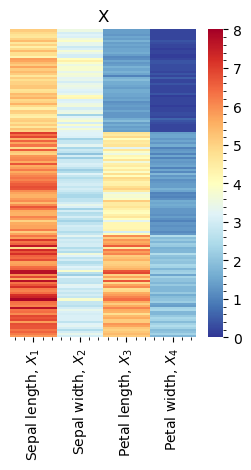

In [23]:
fig,ax = plt.subplots(figsize = (3,4))
ax = sns.heatmap(X_df,cmap = 'RdYlBu_r',
                 xticklabels = list(X_df.columns),
                 yticklabels = False,
                 cbar_kws = {'orientation':'vertical'},
                 vmin = 0,vmax = 8)#与色谱联动配置数据范围映射到色谱上的
plt.title('X')
ax.grid(False)

fig.savefig('Figures/鸢尾花数据.svg')

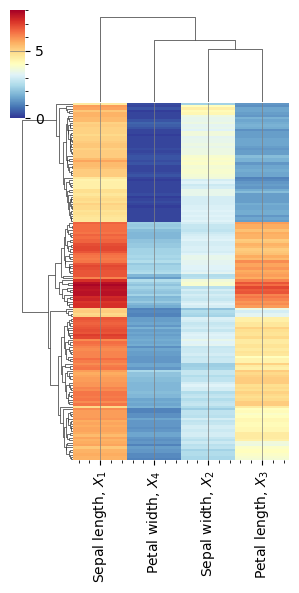

In [27]:
ax = sns.clustermap(X_df,cmap = 'RdYlBu_r',
                    xticklabels = list(X_df.columns),
                    yticklabels = False,
                    figsize = (3,6),
                    vmin = 0,vmax = 8)

plt.savefig('Figures/热图+树状图.svg')

In [29]:
G = X.T@X
print(G.max())
print(G.min())

5223.849999999999
302.33000000000004


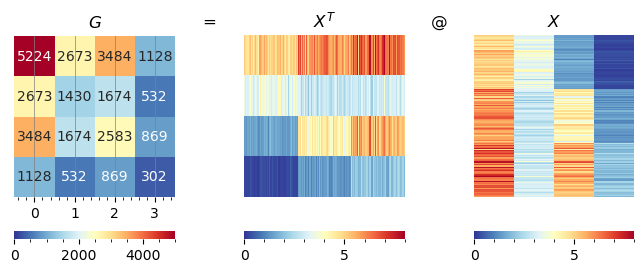

In [53]:
fig,axs = plt.subplots(1,5,figsize = (8,3),
                      gridspec_kw = {'width_ratios':[3,0.5,3,0.5,3]})

plt.sca(axs[0])
ax = sns.heatmap(G,cmap = 'RdYlBu_r',
                 vmax = 5000,vmin = 0,
                 annot = True,
                 fmt = '.0f',
                 cbar_kws = {'orientation':'horizontal'},
                 yticklabels = False,
                 square = 'equal')
plt.title('$G$')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(X.T,cmap = 'RdYlBu_r',
                 vmax = 8,vmin = 0,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = False)
plt.title('$X^T$')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(X,cmap = 'RdYlBu_r',
                 vmax = 8,vmin = 0,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = False)
plt.title('$X$')

plt.savefig('Figures/格拉姆矩阵.svg')

<Axes: >

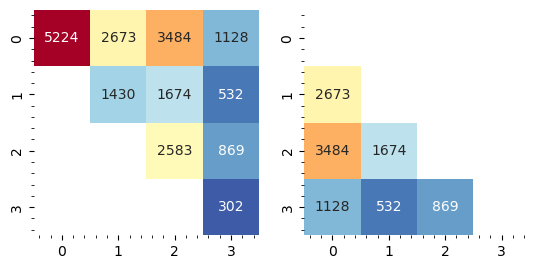

In [71]:
mask_tri = np.zeros_like(G)
#triu中u表示上三角,返回上三角部分索引,然后将这些索引配置为True
#下三角保持还是0
#这时候True自动转换为了1还不是bool
mask_tri[np.triu_indices_from(mask_tri)] = True
#将数组类型实际转换成真的Bool数组,这是个类型不是件简单的int的0,1(虽然一些时候调用会自动转换0,1)
mask_tri = mask_tri.astype(dtype = bool)

fig,axs = plt.subplots(1,2)

sns.heatmap(G,ax = axs[0],
            vmax = 5000,vmin = 0,
            annot = True,
            fmt = '.0f',
            cmap = 'RdYlBu_r',
            square = True,
            #只能接收bool类型数组
            #绘图中传入的bool类型数组,为True的地方为空,处理为True的区域
            mask = ~mask_tri,
            cbar = False,
            linecolor = '0.5')

sns.heatmap(G,ax = axs[1],
            vmax = 5000,vmin = 0,
            annot = True,
            fmt = '.0f',
            cmap = 'RdYlBu_r',
            square = True,
            mask = mask_tri,
            cbar = False,
            linecolor = '0.5')

In [75]:
L = np.linalg.cholesky(G)
L

array([[ 72.27620632,   0.        ,   0.        ,   0.        ],
       [ 36.98907477,   7.88722685,   0.        ,   0.        ],
       [ 48.20064828, -13.76876634,   8.3563496 ,   0.        ],
       [ 15.60873291,  -5.76407773,   4.47500611,   2.33392057]])

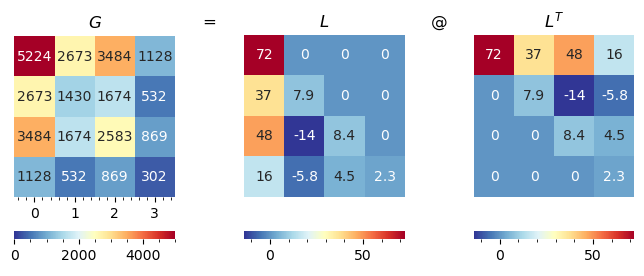

In [85]:
fig,axs = plt.subplots(1,5,figsize = (8,3),
                       gridspec_kw = {'width_ratios':[3,0.5,3,0.5,3]})#这里的3和0.5不是绝对尺寸,而是相对的(换算成比例)

plt.sca(axs[0])
ax = sns.heatmap(G,cmap = 'RdYlBu_r',
                 vmax = 5000,vmin = 0,
                 annot = True,
                 fmt = '.0f',
                 cbar_kws = {'orientation':'horizontal'},
                 yticklabels = False,
                 square = 'equal')
plt.title('$G$')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(L,cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = True)
plt.title('$L$')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(L.T,cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = True)
plt.title('$L^T$')

plt.savefig('Figures/格拉姆矩阵,chol.svg')

In [87]:
Lambdas,V = np.linalg.eig(G)
print(Lambdas)
print(V)

[9.20830507e+03 3.15454317e+02 1.19780429e+01 3.55257020e+00]
[[ 0.75110816  0.2841749   0.50215472  0.32081425]
 [ 0.38008617  0.5467445  -0.67524332 -0.31725607]
 [ 0.51300886 -0.70866455 -0.05916621 -0.48074507]
 [ 0.16790754 -0.34367081 -0.53701625  0.75187165]]


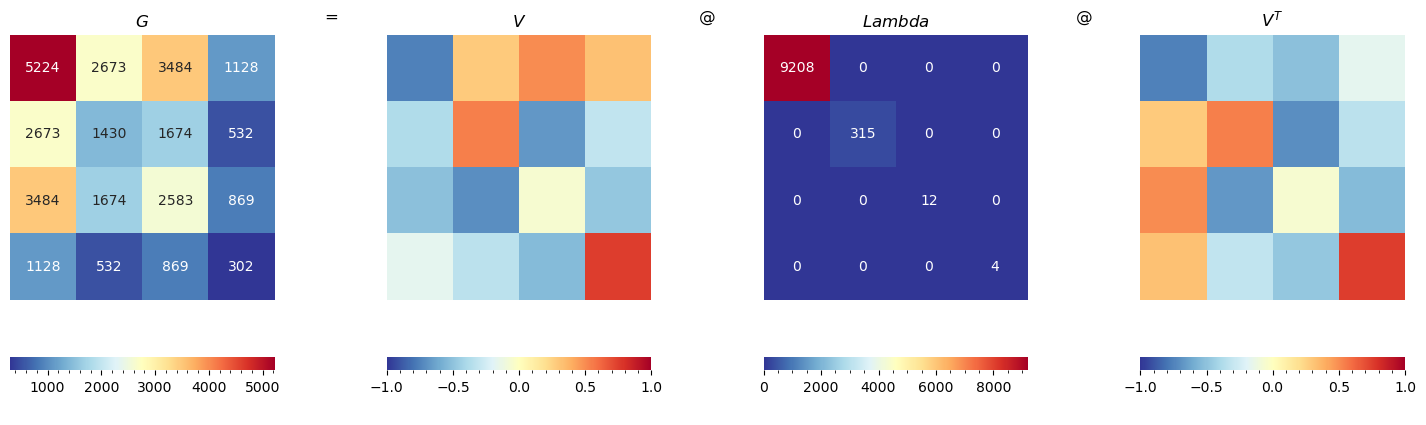

In [105]:
fig,axs = plt.subplots(1,7,figsize = (18,5),
                       gridspec_kw = {'width_ratios':[3,0.5,3,0.5,3,0.5,3]})

plt.sca(axs[0])
ax = sns.heatmap(G,cmap = 'RdYlBu_r',
                 annot = True,
                 fmt = '.0f',
                 cbar_kws = {'orientation':'horizontal'},
                 yticklabels = False,
                 xticklabels = False,
                 square = 'equal')
plt.title('$G$')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V,cmap = 'RdYlBu_r',
                 vmax = 1,vmin = -1,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 square = 'equal')
plt.title('$V$')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(np.diag(Lambdas),cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = True,
                 fmt = '.0f',
                 square = 'equal')
plt.title(r'$Lambda$')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V.T,cmap = 'RdYlBu_r',
                 vmax = 1,vmin = -1,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 square = 'equal')
plt.title('$V^T$')

plt.savefig('Figures/格拉姆矩阵,EVD.svg')

In [103]:
U,S,VT = np.linalg.svd(X,full_matrices = False)
V = VT.T

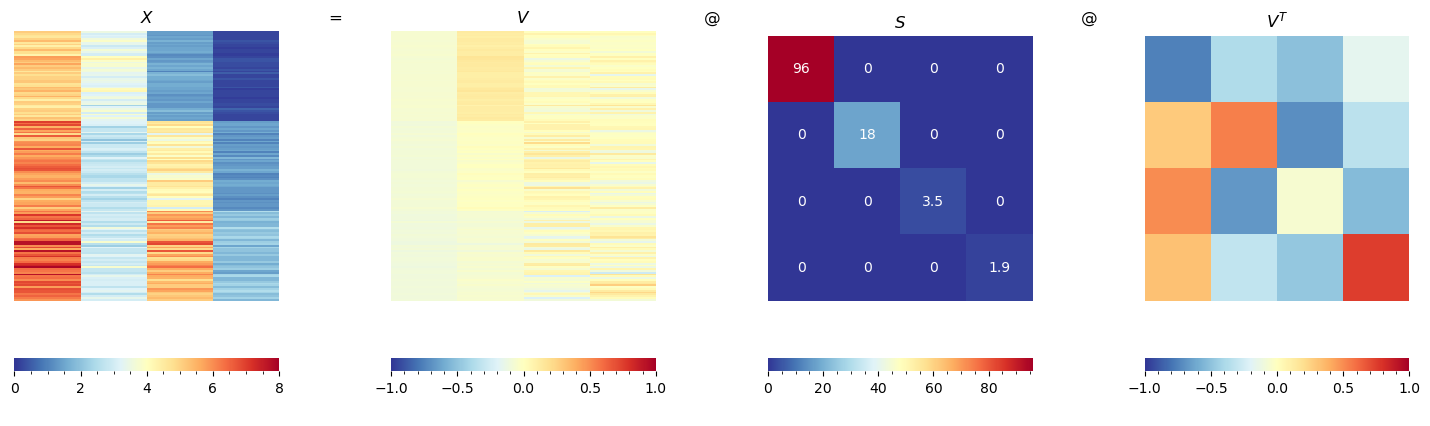

In [107]:
fig,axs = plt.subplots(1,7,figsize = (18,5),
                       gridspec_kw = {'width_ratios':[3,0.5,3,0.5,3,0.5,3]})

plt.sca(axs[0])
ax = sns.heatmap(X,cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation':'horizontal'},
                 vmin = 0,vmax = 8,
                 yticklabels = False,
                 xticklabels = False)
plt.title('$X$')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(U,cmap = 'RdYlBu_r',
                 vmax = 1,vmin = -1,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False)
plt.title('$V$')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(np.diag(S),cmap = 'RdYlBu_r',
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 annot = True,
                 square = 'equal')
plt.title(r'$S$')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V.T,cmap = 'RdYlBu_r',
                 vmax = 1,vmin = -1,
                 cbar_kws = {'orientation':'horizontal'},
                 xticklabels = False,
                 yticklabels = False,
                 square = 'equal')
plt.title('$V^T$')

plt.savefig('Figures/奇异值分解,SVD.svg')

In [109]:
Sigma = X_df.cov()
Corr = X_df.corr()

<Axes: >

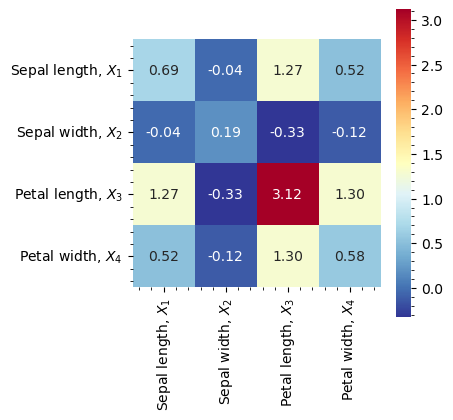

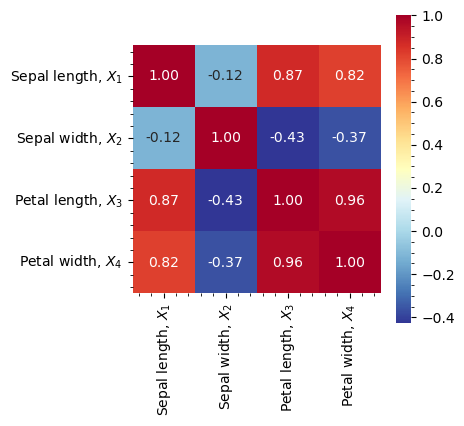

In [115]:
fig,ax = plt.subplots(figsize = (4,4))

sns.heatmap(Sigma,ax = ax,
            annot = True,
            fmt = '.2f',
            cmap = 'RdYlBu_r',
            square = True,
            cbar_kws = {'orientation':'vertical'},
            linecolor = [0.5,0.5,0.5])

fig,ax = plt.subplots(figsize = (4,4))

sns.heatmap(Corr,ax = ax,
            annot = True,
            fmt = '.2f',
            cmap = 'RdYlBu_r',
            square = True,
            cbar_kws = {'orientation':'vertical'},
            linecolor = [0.5,0.5,0.5])

In [119]:
p["axes.grid"] = False

In [127]:
y,x = np.meshgrid(np.linspace(-3,3,16),np.linspace(-3,3,16))

z = (1-x/2. + x**5 + y**3)*np.exp(-x**2 - y**2)

z = z[:-1,:-1]#移出了最后一个z值,为了和15*15的单元格匹配
z_min,z_max = -np.abs(z).max(),np.abs(z).max()#让色谱范围对称,中间值为0

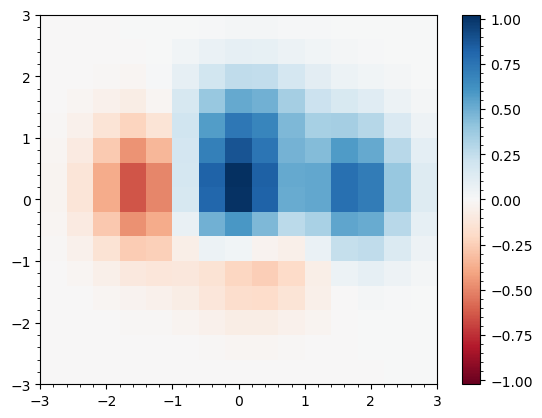

In [129]:
fig,ax = plt.subplots()

#新的更快的方法,这个也能输出矢量图形svg
c = ax.pcolormesh(x,y,z,cmap = 'RdBu',vmin = z_min,vmax = z_max)
ax.axis([x.min(),x.max(),y.min(),y.max()])
fig.colorbar(c,ax = ax)

fig.savefig('Figures/比较_pcolormesh.svg')

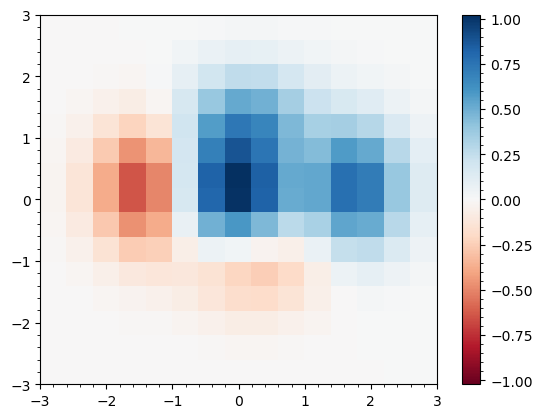

In [131]:
fig,ax = plt.subplots()

#旧的绘制方法
c = ax.pcolor(x,y,z,cmap = 'RdBu',vmin = z_min,vmax = z_max)
#快捷语法,自动根据四个值配置语法(四个是配置xy,两个值仅配置x,不能单独配置y)
ax.axis([x.min(),x.max(),y.min(),y.max()])
fig.colorbar(c,ax = ax)

fig.savefig('Figures/比较_pcolor.svg')

In [138]:
#导入KNN算法模块和内置数据集
from sklearn import neighbors,datasets
from matplotlib.colors import ListedColormap
#导入公司朴素贝叶斯分类器
from sklearn.naive_bayes import GaussianNB

In [140]:
cmap_light = ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000','#00FF00','#0000FF'])

iris = datasets.load_iris()
X = iris.data[:,:2]
y = iris.target

x_min,x_max = 4,8
y_min,y_max = 2,5
xx,yy = np.meshgrid(np.linspace(x_min,x_max,40),np.linspace(y_min,y_max,40))

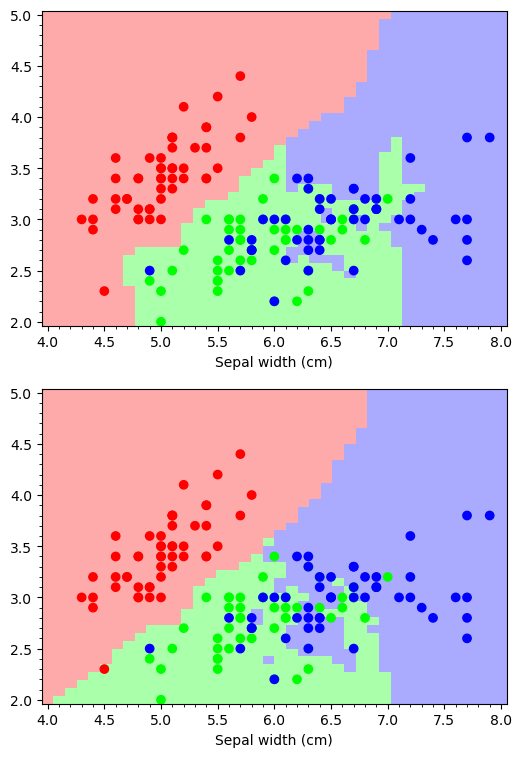

In [152]:
num_neighbors = [2,5]

fig = plt.figure(figsize = (6,9))

for idx,n_neighbors in enumerate(num_neighbors):
    ax = fig.add_subplot(2,1,idx + 1)

    knn = neighbors.KNeighborsClassifier(n_neighbors = n_neighbors)
    knn.fit(X,y)

    Z = knn.predict(np.c_[xx.ravel(),yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.pcolormesh(xx,yy,Z,cmap = cmap_light)
    plt.scatter(X[:,0],X[:,1],c = y,cmap = cmap_bold)
    plt.xlabel('Sepal length (cm)')
    plt.xlabel('Sepal width (cm)')
    plt.axis('tight')

In [155]:
delta = 1/10

x_array = np.linspace(-1 + delta/2,1 - delta/2,int(2/delta))
y_array = np.linspace(-1 + delta/2,1 - delta/2,int(2/delta))

xx,yy = np.meshgrid(x_array,y_array)
zz = xx+yy
complex_zz = xx+yy*1j

colors = plt.cm.rainbow(np.linspace(0,1,len(xx.flatten())))

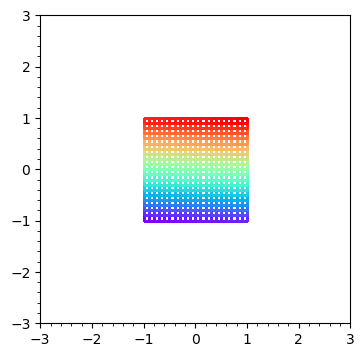

In [161]:
fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(111)
#矩阵中,任何数加上np.nan都能变为空,这里还进行了广播
ax.pcolormesh(xx,yy,zz*0 + np.nan,edgecolors = colors,shading = 'auto')

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)

fig.savefig('Figures/pcolormesh_网格.svg')

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_1735/3811578946.py:38: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(np.real(complex_zz**3),
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_1735/3811578946.py:49: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(np.real(1/complex_zz),
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_1735/3811578946.py:60: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated c

(-3.0, 3.0)

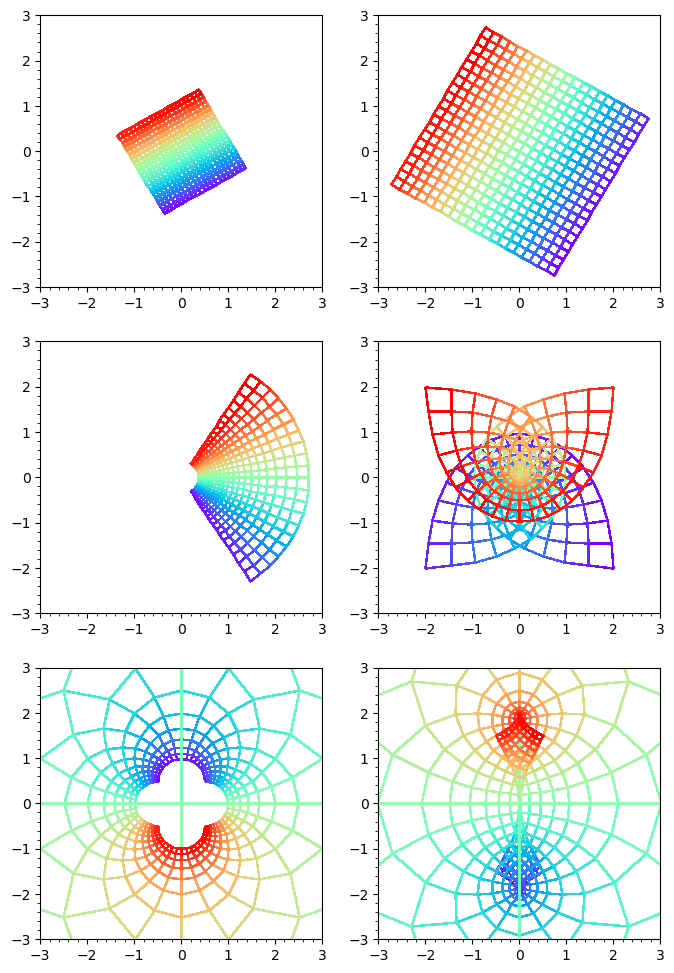

In [179]:
fig = plt.figure(figsize = (8,12))

ax = fig.add_subplot(3,2,1)

#这里的变换是复数的变换
ax.pcolormesh(np.real(complex_zz*np.exp(np.pi/6*1j)),
              np.imag(complex_zz*np.exp(np.pi/6*1j)),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)


ax = fig.add_subplot(3,2,2)

ax.pcolormesh(np.real(2*complex_zz*np.exp(np.pi/3*1j)),
              np.imag(2*complex_zz*np.exp(np.pi/3*1j)),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)


ax = fig.add_subplot(3,2,3)

ax.pcolormesh(np.real(np.exp(complex_zz)),
              np.imag(np.exp(complex_zz)),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)


ax = fig.add_subplot(3,2,4)

ax.pcolormesh(np.real(complex_zz**3),
              np.imag(complex_zz**3),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)


ax = fig.add_subplot(3,2,5)

ax.pcolormesh(np.real(1/complex_zz),
              np.imag(1/complex_zz),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)


ax = fig.add_subplot(3,2,6)

ax.pcolormesh(np.real(complex_zz - 1/complex_zz),
              np.imag(complex_zz - 1/complex_zz),
              zz*0 + np.nan,
              edgecolors = colors,
              shading = 'auto')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)

In [183]:
import matplotlib.image as mpimg#处理图像

In [187]:
img = mpimg.imread('iris_photo.jpg')#传入的常用的照片格式都会转换为rgb格式
print(img)

[[[101 140  31]
  [101 140  31]
  [102 141  32]
  ...
  [ 54  65  35]
  [ 60  71  39]
  [ 62  73  41]]

 [[ 99 138  29]
  [ 99 138  29]
  [100 139  30]
  ...
  [ 49  60  30]
  [ 47  58  26]
  [ 50  61  29]]

 [[ 97 136  27]
  [ 97 136  27]
  [ 99 138  29]
  ...
  [ 48  59  29]
  [ 53  64  32]
  [ 57  68  36]]

 ...

 [[ 28  26  13]
  [ 28  26  13]
  [ 29  27  14]
  ...
  [ 65  95  35]
  [ 63  93  33]
  [ 63  93  33]]

 [[ 27  25  12]
  [ 27  25  12]
  [ 28  26  13]
  ...
  [ 64  94  34]
  [ 62  92  32]
  [ 62  92  32]]

 [[ 27  25  12]
  [ 27  25  12]
  [ 28  26  13]
  ...
  [ 62  93  33]
  [ 62  92  32]
  [ 62  92  32]]]


In [189]:
img.shape

(2990, 2714, 3)

In [191]:
print(img.max())
print(img.min())

255
0


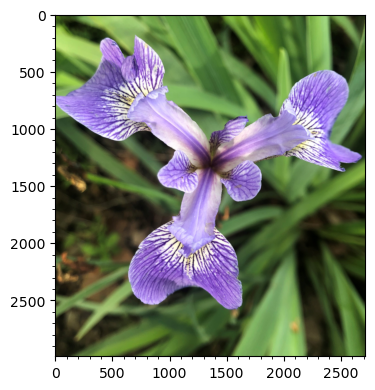

In [193]:
fig,ax = plt.subplots(figsize = (4,8))
imgplot = plt.imshow(img)

fig.savefig('Figures/鸢尾花照片.svg')

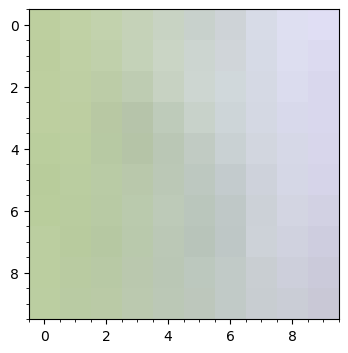

In [207]:
fig,ax = plt.subplots(figsize = (4,8))
imgplot = plt.imshow(img[400:400 + 10,400:400 + 10,:])

fig.savefig('Figures/鸢尾花照片,部分像素.svg')

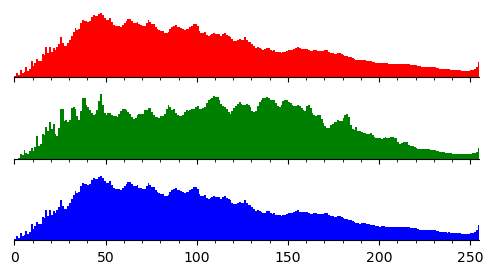

In [229]:
fig,axs = plt.subplots(figsize = (6,3),ncols = 1,nrows = 3,sharex = True)

all_red = img[:,:,0].ravel()
#bins是切成多少个柱子,range是统计的数值的范围
axs[0].hist(all_red,bins = 256,range = (0,256),color = 'r')

axs[0].yaxis.set_ticks([])
axs[0].set_xlim(0,255)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_visible(False)


all_green = img[:,:,1].ravel()
axs[1].hist(all_green,bins = 256,range = (0,256),color = 'g')

axs[1].yaxis.set_ticks([])
axs[1].set_xlim(0,255)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_visible(False)


all_bule = img[:,:,2].ravel()
axs[2].hist(all_red,bins = 256,range = (0,256),color = 'b')

axs[2].yaxis.set_ticks([])
axs[2].set_xlim(0,255)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].spines['left'].set_visible(False)

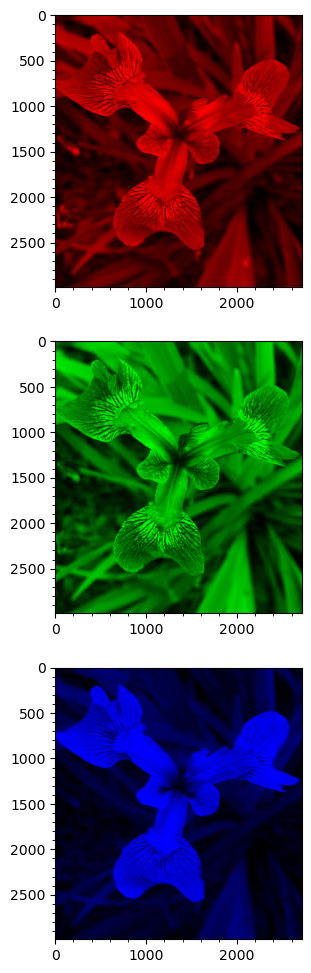

In [237]:
fig,axs = plt.subplots(ncols = 1,nrows = 3,figsize = (4,12))

for i,subplot in zip(range(3),axs):
    #unit8表示无符号8位整数 就是0-255
    temp = np.zeros(img.shape,dtype = 'uint8')
    temp[:,:,i] = img[:,:,i]
    subplot.imshow(temp)

fig.savefig('Figures/鸢尾花照片,三色通道.svg')

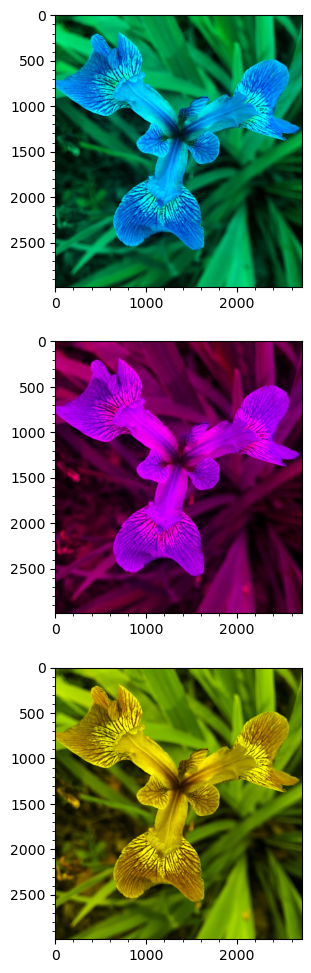

In [239]:
fig,axs = plt.subplots(ncols = 1,nrows = 3,figsize = (4,12))

for i,subplot in zip(range(3),axs):
    zeros = np.zeros(img.shape,dtype = 'uint8')
    temp = np.copy(img)
    temp[:,:,i] = zeros[:,:,i]
    subplot.imshow(temp)

fig.savefig('Figures/鸢尾花照片,保留两个通道.svg')

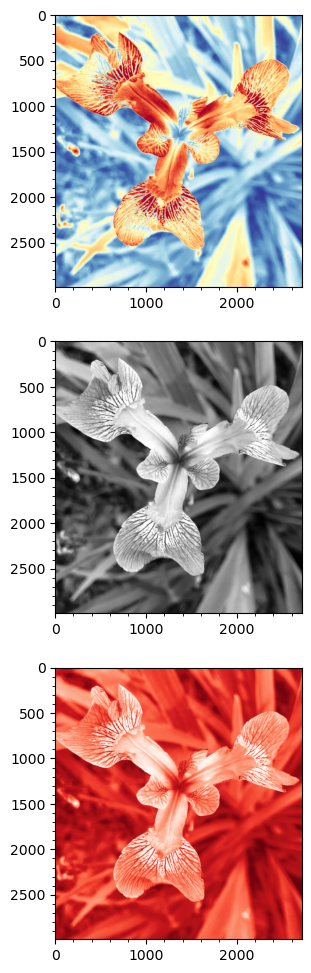

In [241]:
fig,axs = plt.subplots(ncols = 1,nrows = 3,figsize = (4,12))
axs[0].imshow(img[:,:,0],cmap = 'RdYlBu_r')
axs[1].imshow(img[:,:,0],cmap = 'Greys_r')
axs[2].imshow(img[:,:,0],cmap = 'Reds_r')

fig.savefig('Figures/鸢尾花照片,红色通道使用色谱.svg')

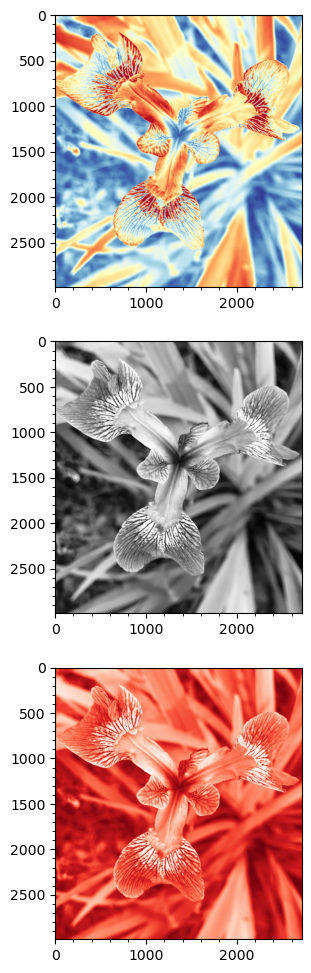

In [243]:
fig,axs = plt.subplots(ncols = 1,nrows = 3,figsize = (4,12))
axs[0].imshow(img[:,:,1],cmap = 'RdYlBu_r')
axs[1].imshow(img[:,:,1],cmap = 'Greys_r')
axs[2].imshow(img[:,:,1],cmap = 'Reds_r')

fig.savefig('Figures/鸢尾花照片,绿色通道使用色谱.svg')

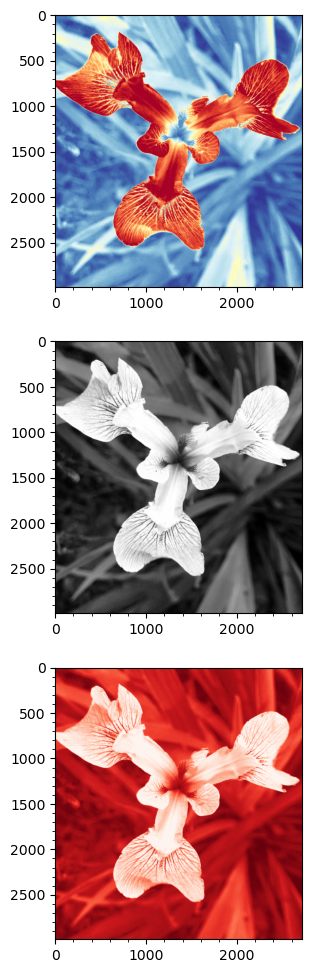

In [245]:
fig,axs = plt.subplots(ncols = 1,nrows = 3,figsize = (4,12))
axs[0].imshow(img[:,:,2],cmap = 'RdYlBu_r')
axs[1].imshow(img[:,:,2],cmap = 'Greys_r')
axs[2].imshow(img[:,:,2],cmap = 'Reds_r')

fig.savefig('Figures/鸢尾花照片,蓝色通道使用色谱.svg')

In [250]:
#图像处理库,第一个color是颜色空间转换模块  第二个io读写模块
from skimage import color
from skimage import io

X = color.rgb2gray(io.imread('iris_photo.jpg'))
X.shape

(2990, 2714)

In [252]:
print(X)
print(X.max())
print(X.min())

[[0.48570039 0.48570039 0.48962196 ... 0.23725294 0.26021686 0.26806   ]
 [0.47785725 0.47785725 0.48177882 ... 0.2176451  0.20923647 0.22100118]
 [0.47001412 0.47001412 0.47785725 ... 0.21372353 0.23276588 0.24845216]
 ...
 [0.09995176 0.09995176 0.10387333 ... 0.33058431 0.32274118 0.32274118]
 [0.0960302  0.0960302  0.09995176 ... 0.32666275 0.31881961 0.31881961]
 [0.0960302  0.0960302  0.09995176 ... 0.32190784 0.31881961 0.31881961]]
1.0
0.0


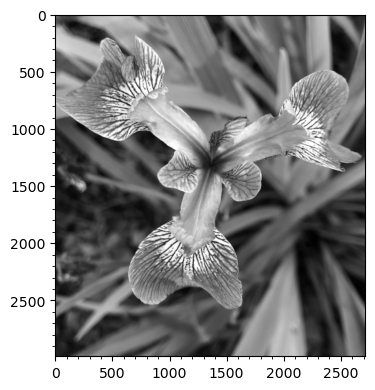

In [256]:
fig,ax = plt.subplots(figsize = (4,8))
plt.imshow(X,cmap = 'gray')

fig.savefig('Figures/鸢尾花照片,灰度.svg')

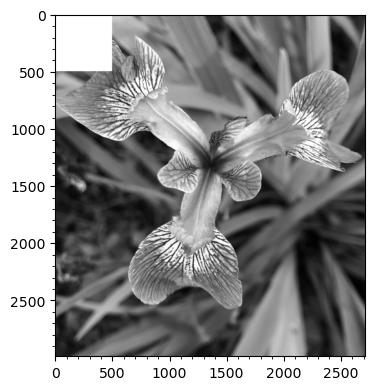

In [258]:
X_copy = np.copy(X)

X_copy[0:500,0:500] = 1

fig,ax = plt.subplots(figsize = (4,8))
plt.imshow(X_copy,cmap = 'gray')

fig.savefig('Figures/鸢尾花照片,灰度,替换.svg')

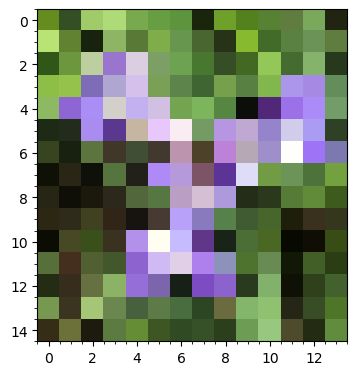

In [264]:
DOWNSAMPLE = 200
image_downsized = img[::DOWNSAMPLE,::DOWNSAMPLE,:]

fig,ax = plt.subplots(figsize = (4,8))
imgplot = plt.imshow(image_downsized)

fig.savefig('Figures/鸢尾花照片,低像素.svg')

In [266]:
image_downsized.shape

(15, 14, 3)

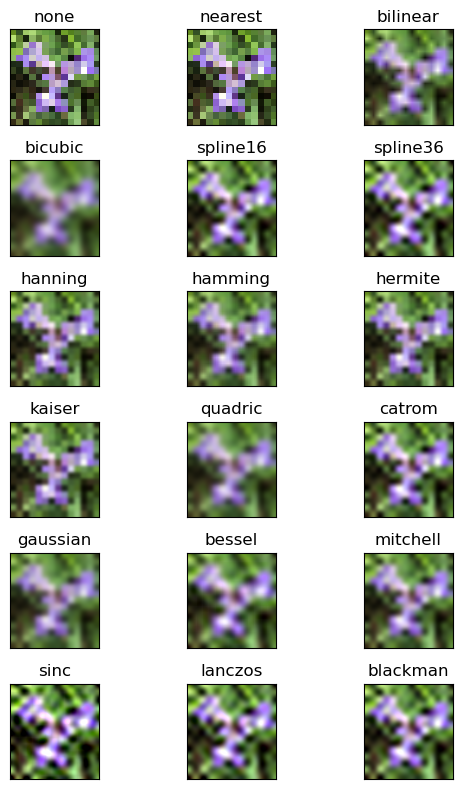

In [274]:
methods = ['none','nearest','bilinear','bicubic','spline16',
           'spline36','hanning','hamming','hermite','kaiser','quadric',
           'catrom','gaussian','bessel','mitchell','sinc','lanczos','blackman']

fig,axs = plt.subplots(nrows = 6,ncols = 3,figsize = (6,8),
                       subplot_kw = {'xticks':[],'yticks':[]})

for ax,interp_method in zip(axs.flat,methods):
    ax.imshow(image_downsized,interpolation = interp_method)
    ax.set_title(str(interp_method))

plt.tight_layout()
fig.savefig('Figures/鸢尾花照片,低像素,插值.svg')

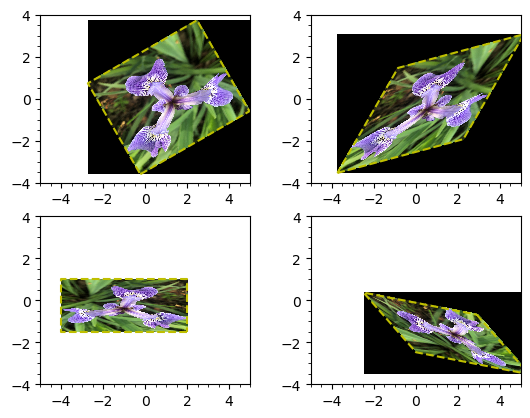

In [298]:
import matplotlib.transforms as mtransforms

def do_plot(ax,Z,transform):
    #在ax上绘制图像Z
    im = ax.imshow(Z,#Z为图像数据
                   interpolation = 'none',#不做插值,逐像素显示
                   origin = 'lower',#放在下边,是按照数据轴的方式不是显示范围,左右没有,默认为x = 0
                   extent = [-2,4,-3,2],#限制范围
                   clip_on = True)#超出范围裁掉不显示
    #传入的集合变换transform  然后对ax本身中的数据做做做表变换
    trans_data = transform + ax.transData
    #将图片应用
    im.set_transform(trans_data)

    x1,x2,y1,y2 = im.get_extent()
    ax.plot([x1,x2,x2,x1,x1],[y1,y1,y2,y2,y1],'y--',transform = trans_data)
    ax.set_xlim(-5,5)
    ax.set_ylim(-4,4)

fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

do_plot(ax1,img,mtransforms.Affine2D().rotate_deg(30))
do_plot(ax2,img,mtransforms.Affine2D().skew_deg(30,15))
do_plot(ax3,img,mtransforms.Affine2D().scale(-1,.5))
do_plot(ax4,img,mtransforms.Affine2D().
    rotate(30).skew_deg(30,15).scale(-1,.5).translate(.5,-1))
fig.savefig('Figures/仿射变换.svg', format='svg')